In [ ]:
# Cargar librerias y modulos
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split  # para partir los datos en conjuntos de entrenamiento y validacion
from sklearn.model_selection import KFold  # para partir la data en k-folds
from sklearn.model_selection import cross_val_score   # para evaluar algoritmos en cross validacion

from sklearn.metrics import accuracy_score, balanced_accuracy_score   # para manejar metricas de desempeño
from sklearn.metrics import classification_report  # para hacer reportes de resultados de clasificacion
from sklearn.metrics import confusion_matrix  # para manejar matrices de confusion

import tensorflow

# Carga la libreria Keras (de Tensorflow) para crear redes neuronales
from tensorflow import keras

# Carga capas de Keras para crear redes neuronales MLP
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import BatchNormalization
from tensorflow.keras.metrics import Precision, Recall, AUC

In [ ]:
df =pd.read_csv('Weather Training Data.csv',sep=',')
df.head()

,row ID,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Row0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0
1,Row1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0
2,Row2,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0
3,Row3,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,...,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,0
4,Row4,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,...,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,99073.0,12.176266,6.390882,-8.5,7.6,12.0,16.8,33.9
MaxTemp,99286.0,23.218513,7.115072,-4.1,17.9,22.6,28.2,48.1
Rainfall,98537.0,2.353024,8.487866,0.0,0.0,0.0,0.8,371.0
Evaporation,56985.0,5.461320,4.162490,0.0,2.6,4.8,7.4,86.2
Sunshine,52199.0,7.615090,3.783008,0.0,4.8,8.4,10.6,14.5
WindGustSpeed,93036.0,39.976966,13.581524,6.0,31.0,39.0,48.0,135.0
WindSpeed9am,98581.0,14.004849,8.902323,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,97681.0,18.650464,8.801827,0.0,13.0,19.0,24.0,87.0
Humidity9am,98283.0,68.866376,19.074951,0.0,57.0,70.0,83.0,100.0
Humidity3pm,97010.0,51.433296,20.777616,0.0,37.0,52.0,65.0,100.0


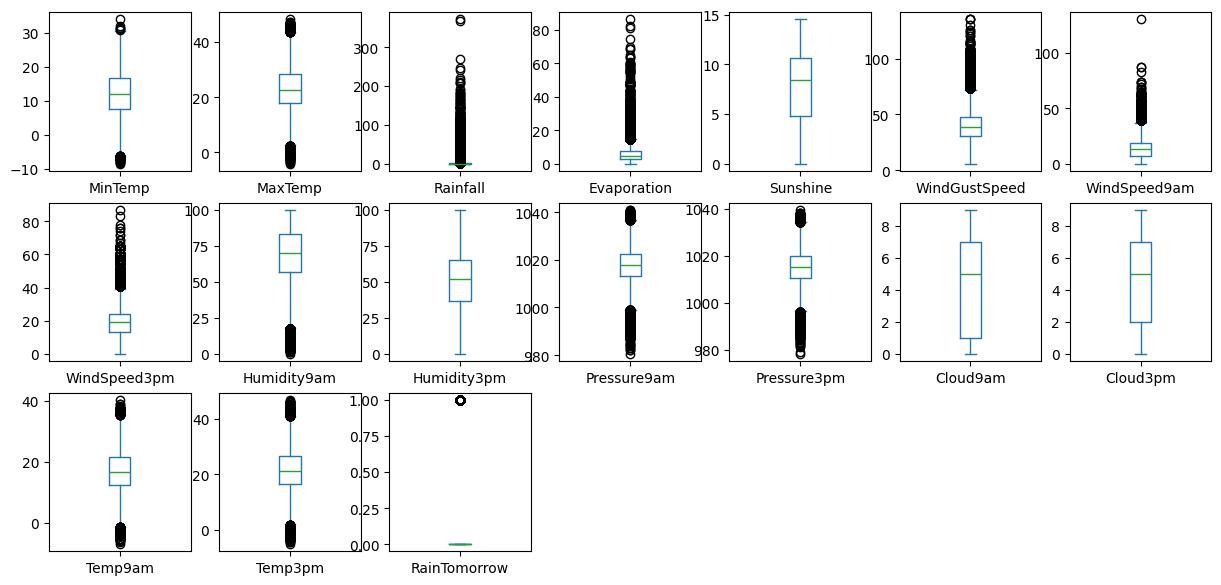

In [ ]:
df.plot(kind='box', subplots=True, layout=(3,7), sharex=False, sharey=False,  figsize=[15,7])
plt.show()

In [ ]:
df.RainTomorrow.value_counts()

,count
RainTomorrow,
0,77157
1,22359


In [ ]:
100*df.isnull().sum() / df.shape[0]

,0
row ID,0.000000
Location,0.000000
MinTemp,0.445155
MaxTemp,0.231119
Rainfall,0.983761
Evaporation,42.737851
Sunshine,47.547128
WindGustDir,6.552715
WindGustSpeed,6.511516
WindDir9am,7.040074


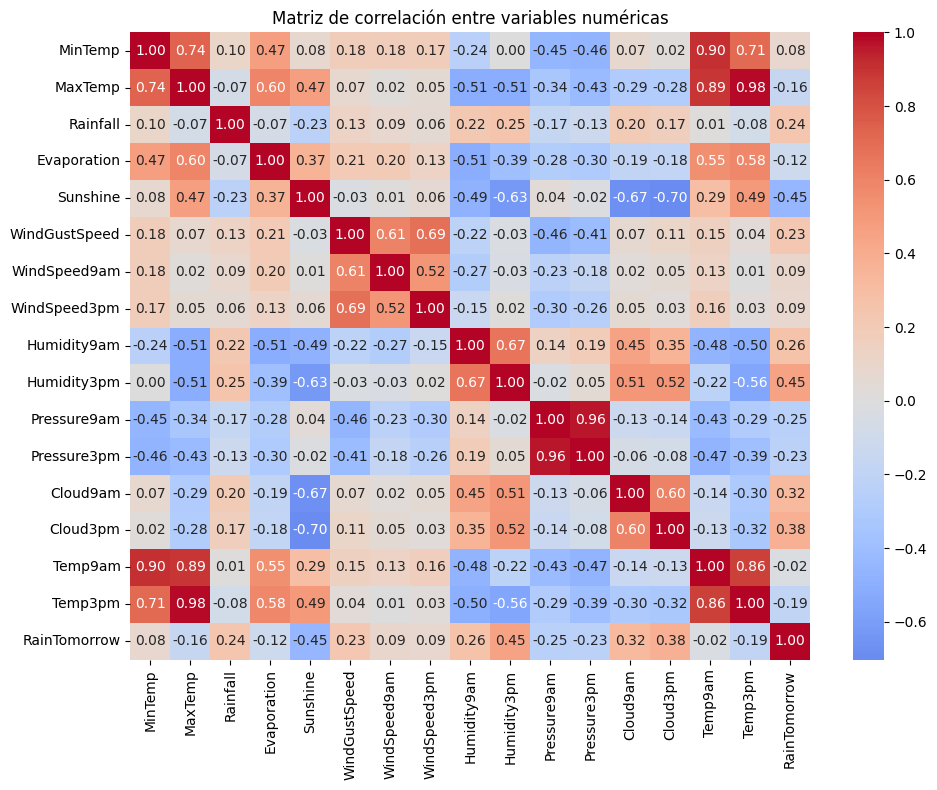

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

In [ ]:
print("Columnas en el DataFrame:")
print(df.columns.tolist())


Columnas en el DataFrame:
['row ID', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']


In [ ]:
cols_to_drop_correlation = ['Pressure3pm','Temp3pm','Temp9am']

df.drop(columns = cols_to_drop_correlation,inplace=True)

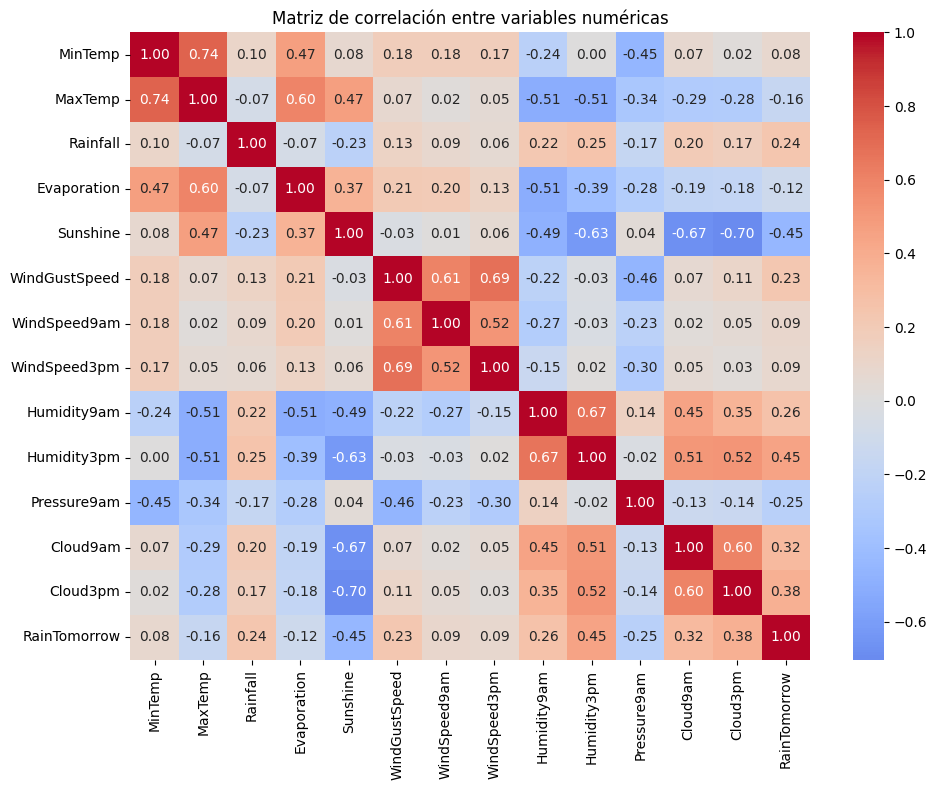

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

De acuerdo a los resultados obtenidos en la sección de arriba, empezaremos el preprocesamiento de los datos. Empezando por el resultado de los bloxpot.

In [ ]:
#Para 'MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm' se considerara un rango de [-10, 50] -> Rango realista en Australia
df = df[(df['MinTemp'] >= -10) & (df['MinTemp'] <= 50)]
df = df[(df['MaxTemp'] >= -10) & (df['MaxTemp'] <= 50)]
#df = df[(df['Temp9am'] >= -10) & (df['Temp9am'] <= 50)]
#df = df[(df['Temp3pm'] >= -10) & (df['Temp3pm'] <= 50)]

In [ ]:
#Para 'Humidity9am', 'Humidity3pm' se considerará un rango de [0, 100] -> Rango físico de humedad:
df = df[(df['Humidity9am'] >= 0) & (df['Humidity9am'] <= 100)]
df = df[(df['Humidity3pm'] >= 0) & (df['Humidity3pm'] <= 100)]

In [ ]:
#Para 'Pressure9am', 'Pressure3pm' se considerará un rango de [980, 1045] -> Presión atmosférica en condiciones normales:
df = df[(df['Pressure9am'] >= 980) & (df['Pressure9am'] <= 1045)]
#df = df[(df['Pressure3pm'] >= 980) & (df['Pressure3pm'] <= 1045)]

In [ ]:
#Para 'WindSpeed9am', 'WindSpeed3pm', 'WindGustSpeed' se considerará un rango de [0, 150] -> Valores arriba de 150 suelen ser errores.
df = df[(df['WindSpeed9am'] >= 0) & (df['WindSpeed9am'] <= 150)]
df = df[(df['WindSpeed3pm'] >= 0) & (df['WindSpeed3pm'] <= 150)]
df = df[(df['WindGustSpeed'] >= 0) & (df['WindGustSpeed'] <= 150)]

In [ ]:
#Para 'Rainfall' se considero valores <=200 mm por que valores arriba de 200 suelen ser errores
df = df[df['Rainfall'] <= 200]

In [ ]:
# Obtener columnas numéricas excepto la variable objetivo
lista_numericas = [col for col in df.select_dtypes(include=['int64', 'float64']).columns
             if col != 'RainTomorrow']
lista_numericas

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Cloud9am',
 'Cloud3pm']

In [ ]:
#Se aplica el recorte por percentiles
for col in lista_numericas:
    low = df[col].quantile(0.005)
    high = df[col].quantile(0.995)
    df = df[(df[col] >= low) & (df[col] <= high)]

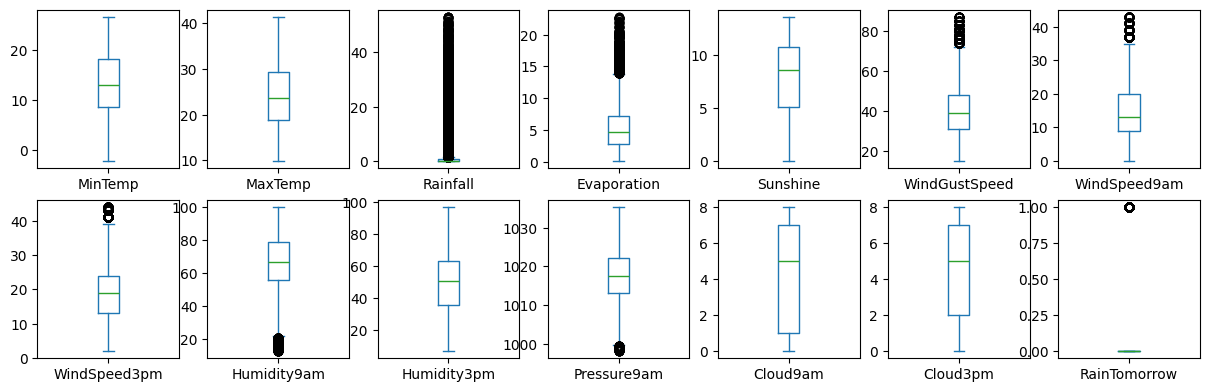

In [ ]:
df.plot(kind='box', subplots=True, layout=(3,7), sharex=False, sharey=False,  figsize=[15,7])
plt.show()

In [ ]:
#Eliminamos la varible row ID por ser insignificante
df.drop(columns=['row ID'], inplace=True)

In [ ]:
100*df.isnull().sum() / df.shape[0]

,0
Location,0.000000
MinTemp,0.000000
MaxTemp,0.000000
Rainfall,0.000000
Evaporation,0.000000
Sunshine,0.000000
WindGustDir,0.013079
WindGustSpeed,0.000000
WindDir9am,2.540023
WindDir3pm,0.000000


In [ ]:
#Se imputó la moda en estas dos variables que presentaban un porcentaje de nulo. Se hizo esto para evitar eliminar esos registros y perder datos innecesariamente.
cols_categoricas = ['WindGustDir','WindDir9am']

for col in cols_categoricas:
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipython-input-160379296.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
100*df.isnull().sum() / df.shape[0]

,0
Location,0.0
MinTemp,0.0
MaxTemp,0.0
Rainfall,0.0
Evaporation,0.0
Sunshine,0.0
WindGustDir,0.0
WindGustSpeed,0.0
WindDir9am,0.0
WindDir3pm,0.0


In [ ]:
#Creamos las variables one hot encoding para las siguientes variables
df = pd.get_dummies(df, columns=['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'], drop_first=True)

In [ ]:
df.dtypes

,0
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
...,...
WindDir3pm_SW,bool
WindDir3pm_W,bool
WindDir3pm_WNW,bool
WindDir3pm_WSW,bool


Con el dataset listo empezemos con la separación en train/test

In [ ]:
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
X_train.shape

(30582, 84)

In [ ]:
X_test.shape

(7646, 84)

In [ ]:
# Estandarizar variables numéricas
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()

X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train_std[lista_numericas] = scaler.fit_transform(X_train_std[lista_numericas])
X_test_std[lista_numericas] = scaler.transform(X_test_std[lista_numericas])

In [ ]:
X_train_std.describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,30582.0,-1.974892e-16,1.000016,-2.460892,-0.761354,-0.046595,0.779348,2.113565
MaxTemp,30582.0,4.934905e-16,1.000016,-2.127604,-0.787027,-0.048957,0.794552,2.617135
Rainfall,30582.0,-6.505525e-18,1.000016,-0.344963,-0.344963,-0.344963,-0.236541,9.268439
Evaporation,30582.0,4.089187e-17,1.000016,-1.548755,-0.757788,-0.149352,0.580772,5.326574
Sunshine,30582.0,-2.695146e-16,1.000016,-2.077777,-0.705055,0.237008,0.802246,1.582813
WindGustSpeed,30582.0,-5.250888e-17,1.000016,-2.034090,-0.729936,-0.077858,0.655729,3.834606
WindSpeed9am,30582.0,7.969268e-17,1.000016,-1.852381,-0.738128,0.004708,0.623738,3.471275
WindSpeed3pm,30582.0,1.951658e-16,1.000016,-2.154507,-0.792765,-0.049996,0.568977,3.044872
Humidity9am,30582.0,1.951658e-16,1.000016,-3.044119,-0.607627,0.015662,0.695613,1.885528
Humidity3pm,30582.0,1.793666e-16,1.000016,-2.211462,-0.716698,0.056455,0.674978,2.427458


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
clases = np.unique(y_train)
pesos = compute_class_weight(
    class_weight='balanced',
    classes=clases,
    y=y_train
)

pesos_dict = {clases[i]: pesos[i] for i in range(len(clases))}
pesos_dict

{np.int64(0): np.float64(0.63685964181591),
 np.int64(1): np.float64(2.326688983566646)}

In [ ]:
#Librerías
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras import regularizers

In [ ]:
# Modelo 2 red simple

model2 = Sequential([


    Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),

    Dense(1, activation='sigmoid')
])

# Compilar
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',
             Precision(name='precision'),
             Recall(name='recall'),
             AUC(name='auc')]
)

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Modelo 3 red compleja
model3 = Sequential([

    Dense(256, kernel_regularizer=regularizers.l2(1e-3),
          input_shape=(X_train_std.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    Dense(128, kernel_regularizer=regularizers.l2(1e-3)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.25),

    Dense(64, kernel_regularizer=regularizers.l2(1e-3)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.25),


    Dense(32, kernel_regularizer=regularizers.l2(1e-3)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.25),

    Dense(16),
    BatchNormalization(),
    Activation('relu'),

    Dense(8),
    BatchNormalization(),
    Activation('relu'),

    Dense(1, activation='sigmoid')
])

# Compilar
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',
             Precision(name='precision'),
             Recall(name='recall'),
             AUC(name='auc')]
)

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 8)              │             

 Total params: 67,681 (264.38 KB)

 Trainable params: 66,673 (260.44 KB)

 Non-trainable params: 1,008 (3.94 KB)

In [ ]:
# Modelo 1 red media

model = Sequential([
    Dense(128, kernel_regularizer=regularizers.l2(1e-4),
          input_shape=(X_train_std.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.2),

    Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.15),


    Dense(32, kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.15),

    Dense(16),
    BatchNormalization(),
    Activation('relu'),

    Dense(1, activation='sigmoid')
])

# Compilar
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',
             Precision(name='precision'),
             Recall(name='recall'),
             AUC(name='auc')]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │        10,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,721 (88.75 KB)

 Trainable params: 22,241 (86.88 KB)

 Non-trainable params: 480 (1.88 KB)

In [ ]:
#red media
history = model.fit(
    X_train_std, y_train,
    #validation_data=(X_test_std, y_test),
    validation_split = 0.2,
    epochs=50,
    batch_size=32,
    class_weight=pesos_dict
)

Epoch 1/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7221 - auc: 0.8076 - loss: 0.5548 - precision: 0.4182 - recall: 0.7547 - val_accuracy: 0.7742 - val_auc: 0.8838 - val_loss: 0.4705 - val_precision: 0.4884 - val_recall: 0.8254
Epoch 2/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7799 - auc: 0.8690 - loss: 0.4734 - precision: 0.4896 - recall: 0.8097 - val_accuracy: 0.7796 - val_auc: 0.8889 - val_loss: 0.4650 - val_precision: 0.4958 - val_recall: 0.8412
Epoch 3/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7861 - auc: 0.8773 - loss: 0.4639 - precision: 0.5048 - recall: 0.8211 - val_accuracy: 0.7932 - val_auc: 0.8917 - val_loss: 0.4404 - val_precision: 0.5152 - val_recall: 0.8141
Epoch 4/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7826 - auc: 0.8769 - loss: 0.4619 - precision: 0.4987 - recall: 0.8197 - val_accuracy: 0.7872 - val_auc: 0.8923 - val_loss: 0.4441 - val_precision: 0.5062 - val_recall: 0.8239
Epoch 5/50
765/765 ━━━━━━━━━━━━

In [ ]:
#red simple
history2 = model2.fit(
    X_train_std, y_train,
    #validation_data=(X_test_std, y_test),
    validation_split = 0.2,
    epochs=50,
    batch_size=32,
    class_weight=pesos_dict
)

Epoch 1/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7558 - auc: 0.8361 - loss: 0.4986 - precision: 0.4563 - recall: 0.7606 - val_accuracy: 0.7800 - val_auc: 0.8854 - val_loss: 0.4573 - val_precision: 0.4962 - val_recall: 0.8397
Epoch 2/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7901 - auc: 0.8821 - loss: 0.4339 - precision: 0.5007 - recall: 0.8014 - val_accuracy: 0.7939 - val_auc: 0.8886 - val_loss: 0.4270 - val_precision: 0.5164 - val_recall: 0.8059
Epoch 3/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7996 - auc: 0.8900 - loss: 0.4243 - precision: 0.5235 - recall: 0.8108 - val_accuracy: 0.8037 - val_auc: 0.8926 - val_loss: 0.4152 - val_precision: 0.5317 - val_recall: 0.8074
Epoch 4/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8059 - auc: 0.8935 - loss: 0.4157 - precision: 0.5273 - recall: 0.8156 - val_accuracy: 0.7906 - val_auc: 0.8944 - val_loss: 0.4422 - val_precision: 0.5110 - val_recall: 0.8382
Epoch 5/50
765/765 ━━━━━━━━━━━━━

In [ ]:
#red compleja
history3 = model3.fit(
    X_train_std, y_train,
    #validation_data=(X_test_std, y_test),
    validation_split = 0.2,
    epochs=50,
    batch_size=32,
    class_weight=pesos_dict
)

Epoch 1/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7411 - auc: 0.7824 - loss: 0.9555 - precision: 0.4256 - recall: 0.6600 - val_accuracy: 0.7654 - val_auc: 0.8811 - val_loss: 0.7691 - val_precision: 0.4776 - val_recall: 0.8495
Epoch 2/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7724 - auc: 0.8615 - loss: 0.7353 - precision: 0.4787 - recall: 0.8020 - val_accuracy: 0.7804 - val_auc: 0.8859 - val_loss: 0.6285 - val_precision: 0.4969 - val_recall: 0.8352
Epoch 3/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7771 - auc: 0.8679 - loss: 0.6213 - precision: 0.4903 - recall: 0.8164 - val_accuracy: 0.7850 - val_auc: 0.8871 - val_loss: 0.5369 - val_precision: 0.5032 - val_recall: 0.8277
Epoch 4/50
765/765 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7855 - auc: 0.8763 - loss: 0.5422 - precision: 0.5010 - recall: 0.8157 - val_accuracy: 0.7772 - val_auc: 0.8871 - val_loss: 0.4997 - val_precision: 0.4924 - val_recall: 0.8292
Epoch 5/50
765/765 ━━━━━━━━━━━

In [ ]:
#resultados red  media
resultados = model.evaluate(X_test_std, y_test, verbose=0)

loss = resultados[0]
accuracy = resultados[1]
precision = resultados[2]
recall = resultados[3]
auc = resultados[4]

print(f"Loss (pérdida): {loss:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"AUC: {auc:.4f}")


Loss (pérdida): 0.4494
Accuracy: 80.07%
Precision: 52.39%
Recall: 79.31%
AUC: 0.8864


In [ ]:
#resultados red simple
resultados = model2.evaluate(X_test_std, y_test, verbose=0)

loss = resultados[0]
accuracy = resultados[1]
precision = resultados[2]
recall = resultados[3]
auc = resultados[4]

print(f"Loss (pérdida): {loss:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"AUC: {auc:.4f}")

Loss (pérdida): 0.4672
Accuracy: 79.96%
Precision: 52.26%
Recall: 78.21%
AUC: 0.8777


In [ ]:
#resultados red compeja
resultados = model3.evaluate(X_test_std, y_test, verbose=0)

loss = resultados[0]
accuracy = resultados[1]
precision = resultados[2]
recall = resultados[3]
auc = resultados[4]

print(f"Loss (pérdida): {loss:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"AUC: {auc:.4f}")

Loss (pérdida): 0.4626
Accuracy: 79.01%
Precision: 50.69%
Recall: 84.54%
AUC: 0.8929


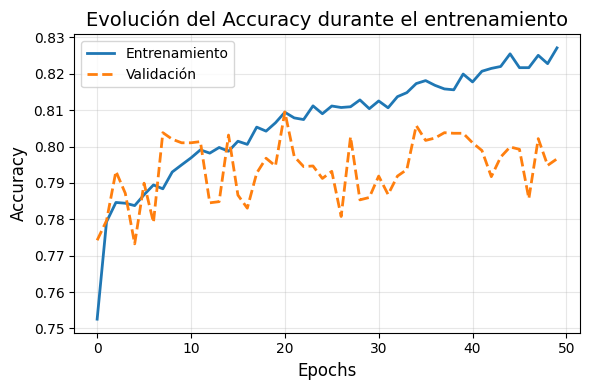

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'],
         label='Entrenamiento',
         linewidth=2)

plt.plot(history.history['val_accuracy'],
         label='Validación',
         linewidth=2,
         linestyle='--')

plt.title('Evolución del Accuracy durante el entrenamiento', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

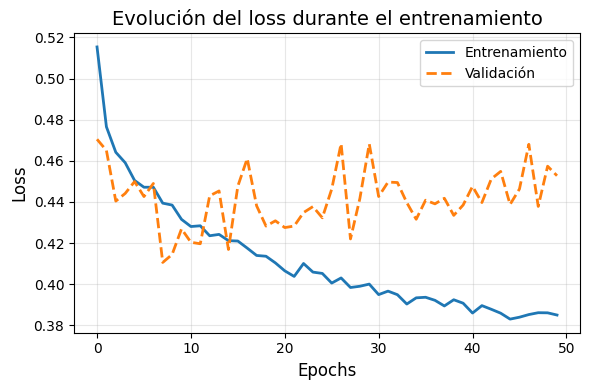

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'],
         label='Entrenamiento',
         linewidth=2)

plt.plot(history.history['val_loss'],
         label='Validación',
         linewidth=2,
         linestyle='--')

plt.title('Evolución del loss durante el entrenamiento', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


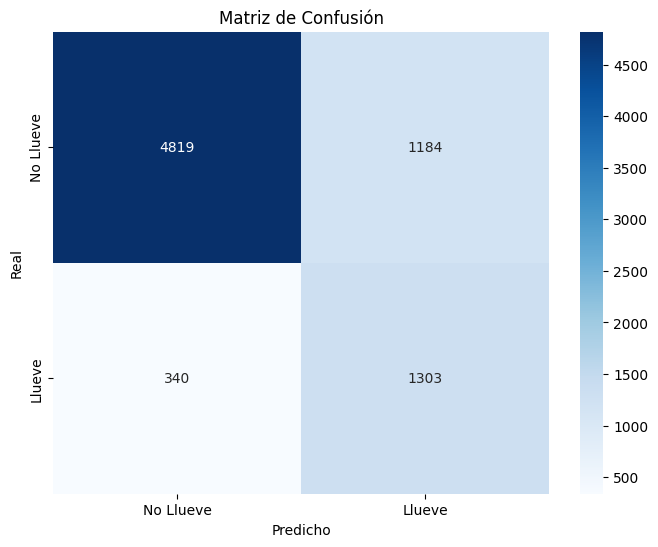

In [ ]:
# Versión simple y directa
y_pred_prob = model.predict(X_test_std)
y_pred = (y_pred_prob > 0.5).astype(int)

conf_mx = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_mx, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.xticks(ticks=[0.5, 1.5], labels=['No Llueve', 'Llueve'])
plt.yticks(ticks=[0.5, 1.5], labels=['No Llueve', 'Llueve'])
plt.show()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,y_pred,target_names=['No Llueve','Llueve']))

              precision    recall  f1-score   support

   No Llueve       0.93      0.80      0.86      6003
      Llueve       0.52      0.79      0.63      1643

    accuracy                           0.80      7646
   macro avg       0.73      0.80      0.75      7646
weighted avg       0.85      0.80      0.81      7646

